(32000, 11)


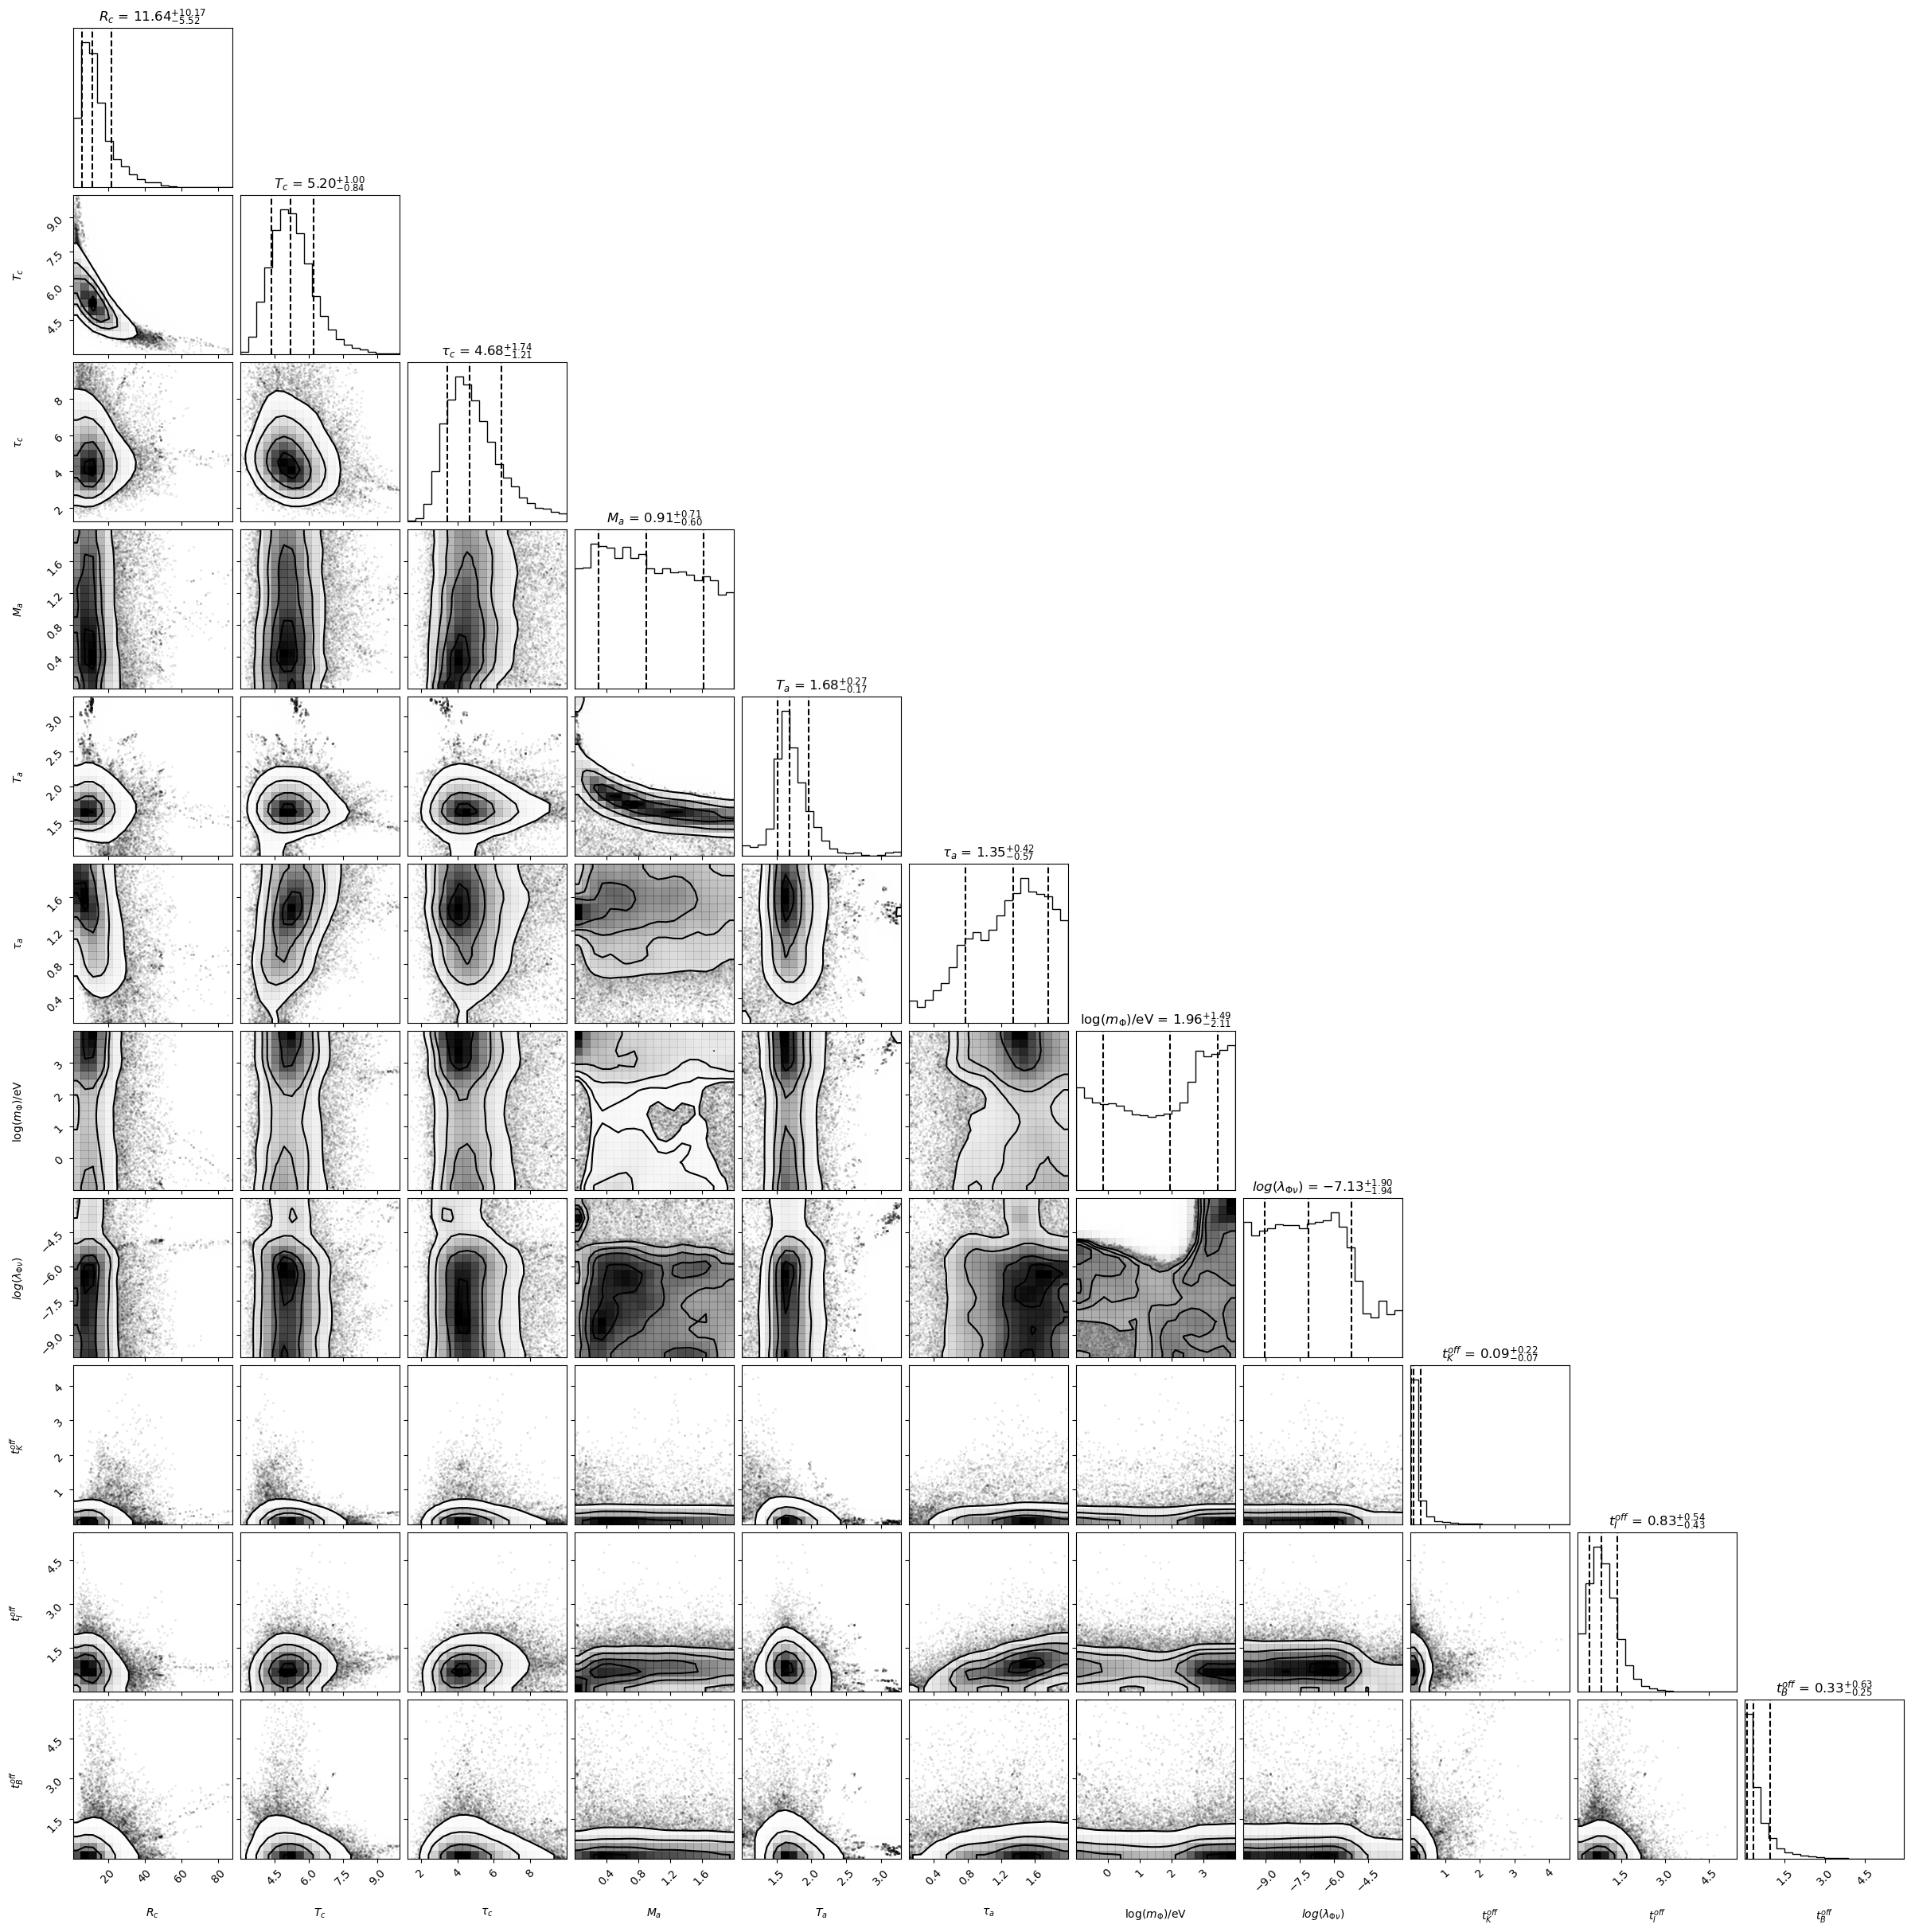

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import definition as df

data_toff = np.load(r'F:/Neutrino_SI/Bin/1d_11p_5e5_p32_log.npy')
label_11= ['$R_c$', '$T_c$', r'$\tau_c$',
        '$M_a$', '$T_a$', r'$\tau_a$',
        r'log($m_{\Phi}$)/eV', r'$log({\lambda}_{\Phi \nu})$',        
        # r'$m_{\Phi}$/eV', r'${\lambda}_{\Phi \nu}/10^{-8}$',
        r'$t^{off}_K$', r'$t^{off}_I$', r'$t^{off}_B$']

print(data_toff.shape)
fig = corner.corner(data_toff, labels=label_11, show_titles=True, 
                    quantiles=[0.16, 0.5, 0.84], smooth=1.0,
                    title_fmt='.2f', title_kwargs={"fontsize": 12})
fig

(32000, 8)
Removed no burn in
R_c/km: Peak=11.65, 1-sigma HPD=[-6.60, +10.61]
T_c/MeV: Peak=4.24, 1-sigma HPD=[-0.61, +0.95]
\tau_c/s: Peak=4.48, 1-sigma HPD=[-1.24, +1.88]
M_a/M_\odot: Peak=0.10, 1-sigma HPD=[-0.08, +0.83]
T_a/MeV: Peak=2.02, 1-sigma HPD=[-0.23, +0.35]
\tau_a/s: Peak=0.46, 1-sigma HPD=[-0.17, +0.70]
results of Case 3


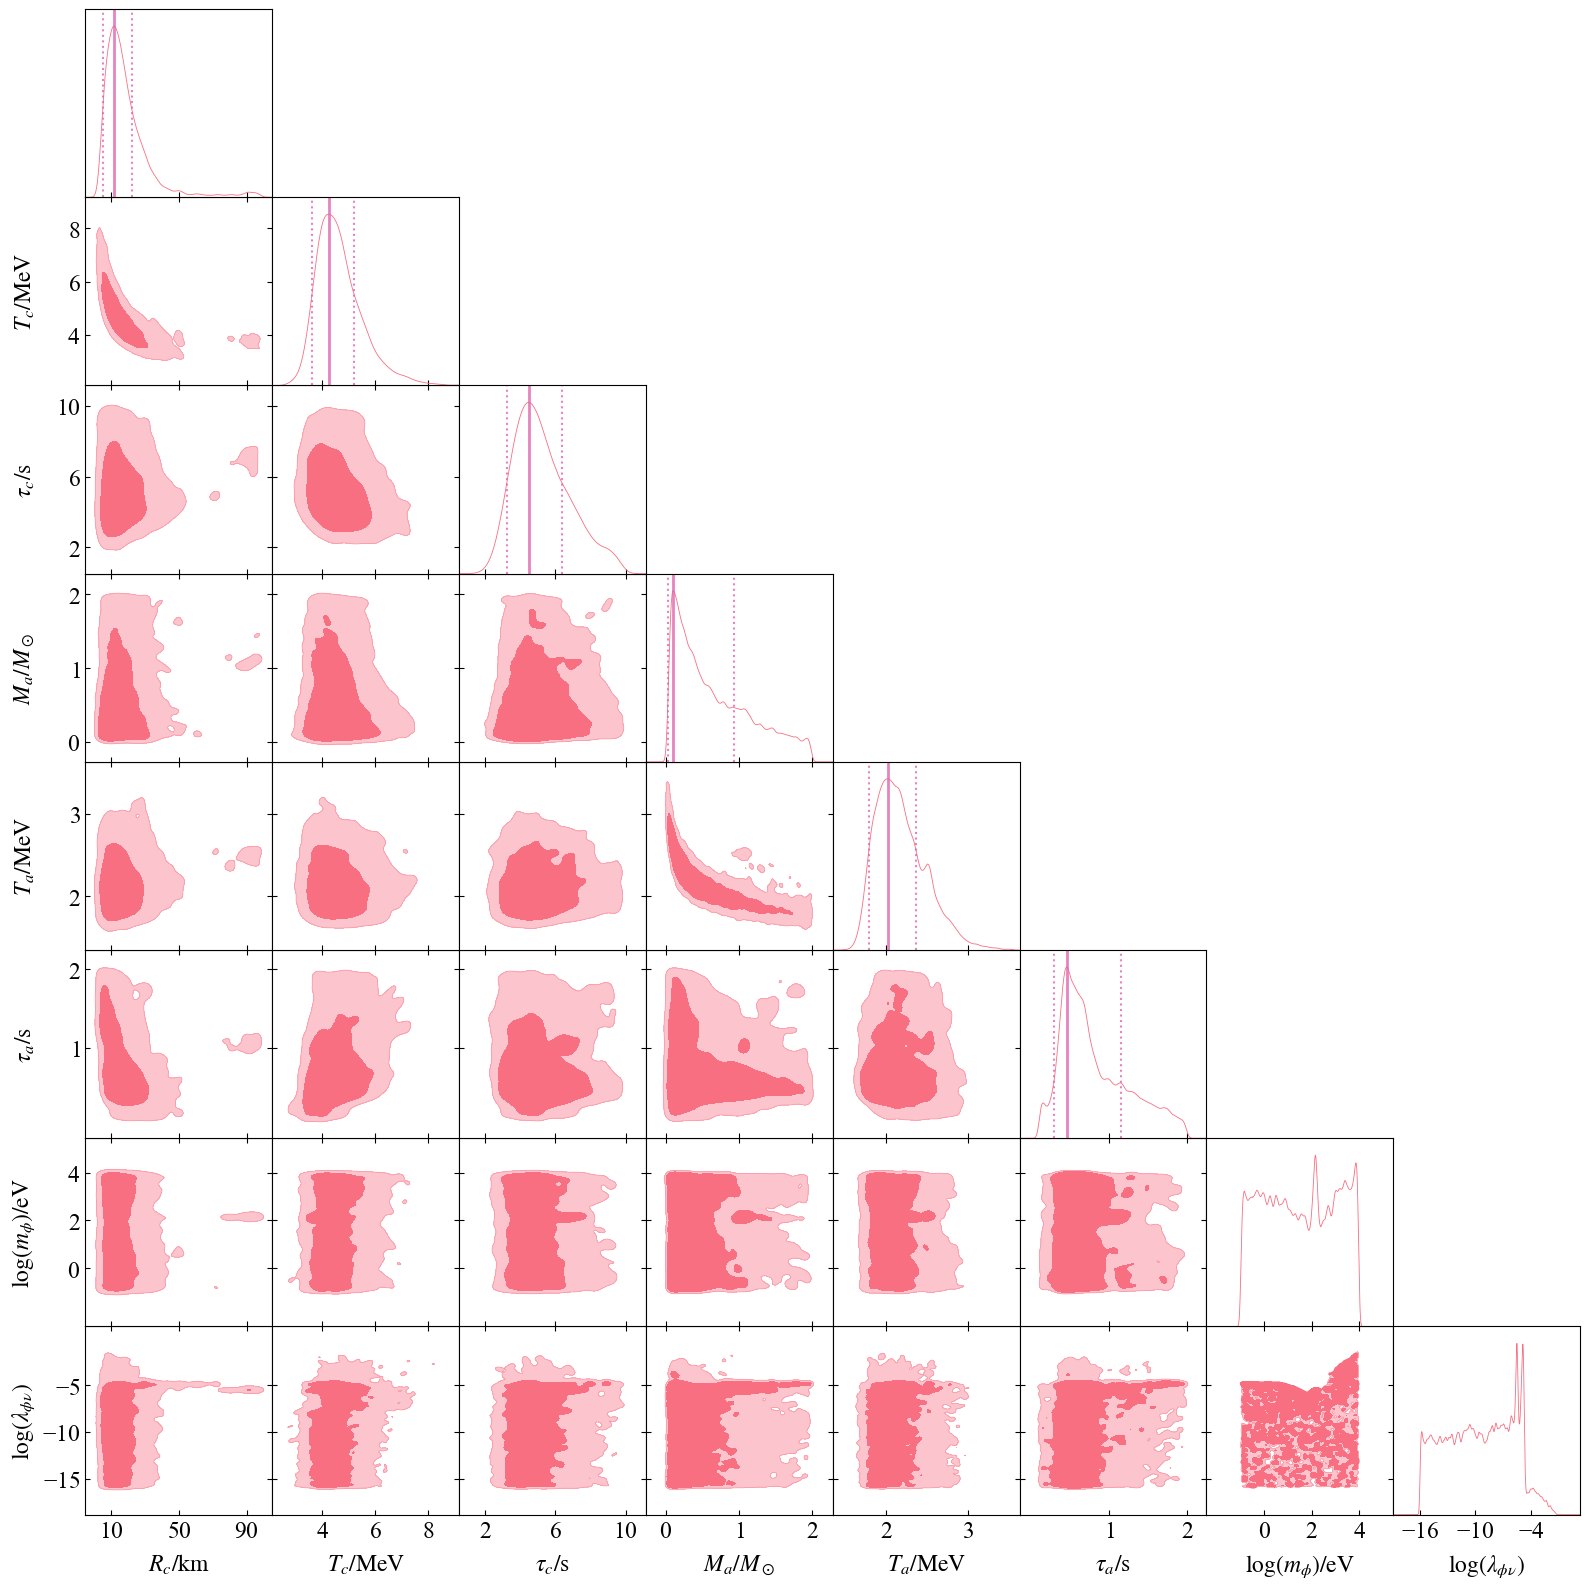

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import definition as df

Case = 3

# Your original labels (display names with LaTeX)
name_8p = [
            r'R_c/km', r'T_c/MeV', r'\tau_c/s' , 
            r'M_a/M_\odot', r'T_a/MeV', r'\tau_a/s',
            r'\log(m_\phi)/eV', r'\log(\lambda_{\phi\nu})'
              ]

label_8p = [
            r'R_c/{\rm km}', r'T_c/{\rm MeV}', r'\tau_c/{\rm s}' , 
            r'M_a/M_\odot', r'T_a/{\rm MeV}', r'\tau_a/{\rm s}',
            r'\log(m_\phi)/{\rm eV}', r'\log(\lambda_{\phi\nu})'
              ]

# Case I
if Case == 1:
    data_1d = np.load(r'.\Bin\smellycat260817\data\InverseS\8p_5e5_p32_IS_1e-2Tnu.npy')
# Case II
if Case == 2:
    data_1d = np.load(r'.\Bin\smellycat260817\data\InverseS\8p_5e5_p32_osc_IS_1e-2Tnu.npy')
# Case III
if Case == 3:
    data_1d = np.load(r'.\Bin\smellycat260817\data\TypeI\8p_5e5_p32_osc_TPI_1e-2Tnu.npy')
elif Case not in [1, 2, 3]:
    print("Invalid Case number. Please choose 1, 2, or 3.")
    
print(data_1d.shape)  # Should be (N_samples, 8)
sample_8p = MCSamples(samples=data_1d[:,:], names=name_8p
                    , labels=label_8p, label='1d'
                    )


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

# sample_8p.updateSettings({'smooth_scale_1D': 1.5, 'smooth_scale_2D': 1.5})


g = plots.get_subplot_plotter()
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 20


# Extract the marginal statistics from your samples (No longer needed for HPD limits directly, 
# but keeping the triangle plot generation unchanged)
g.triangle_plot([sample_8p], 
                filled=True,          
                plot_datapoints=False,
                contour_colors=['#f76f81'],
                )

# Loop through the list of parameter names using enumerate to get the index 'i'
for i, param_name in enumerate(name_8p[:-2]):
    
    # 1. Extract the 1D density grid for this specific parameter
    density = sample_8p.get1DDensity(param_name)
    x = density.x
    P = density.P
    
    # 2. Sort probabilities in descending order to find HPD regions
    sort_idx = np.argsort(P)[::-1]
    sorted_P = P[sort_idx]
    
    # Calculate cumulative probability mass
    cum_prob = np.cumsum(sorted_P)
    cum_prob /= cum_prob[-1] # Normalize the probabilities
    
    # 3. Boolean Indexing: Create masks for the required probability mass
    # 1-sigma is ~68.27%, 2-sigma is ~95.45%
    idx_1sigma = sort_idx[cum_prob <= 0.6827]
    idx_2sigma = sort_idx[cum_prob <= 0.9545]
    
    peak_idx = np.argmax(P)
    peak_value = x[peak_idx]
    # Get the specific 1D diagonal axis for this parameter
    ax = g.subplots[i, i]
    
    # 4. Find Edges and Draw the 1-sigma HPD lines
    if len(idx_1sigma) > 0:
        lower_1sigma = np.min(x[idx_1sigma])
        upper_1sigma = np.max(x[idx_1sigma])
        # add a horizontal line at the 1-sigma HPD level
        # ax.axhline(P[idx_1sigma].min(), color='blue', ls='-', lw=1.5, alpha=0.8)

        # add a vertical line at the peak value
        ax.axvline(peak_value, color='#df65b0', ls='-', lw=2, alpha=0.8)
        print(f"{param_name}: Peak={peak_value:.2f}, 1-sigma HPD=[-{peak_value-lower_1sigma:.2f}, +{upper_1sigma-peak_value:.2f}]")

        ax.axvline(lower_1sigma, color='#df65b0', ls=':', lw=1.5, alpha=0.8)
        ax.axvline(upper_1sigma, color='#df65b0', ls=':', lw=1.5, alpha=0.8)
        
    # Find Edges and Draw the 2-sigma HPD lines
    # if len(idx_2sigma) > 0:
    #     lower_2sigma = np.min(x[idx_2sigma])
    #     upper_2sigma = np.max(x[idx_2sigma])
    #     ax.axvline(lower_2sigma, color='red', ls='--', lw=1.5, alpha=0.8)
    #     ax.axvline(upper_2sigma, color='red', ls='--', lw=1.5, alpha=0.8)

g.fig.align_ylabels()
g.fig.align_xlabels()

if Case == 1:
    g.export(r'F:\Neutrino_SI\Plots\8p_I.pdf')
if Case == 2:
    g.export(r'F:\Neutrino_SI\Plots\8p_II.pdf')
if Case == 3:
    g.export(r'F:\Neutrino_SI\Plots\8p_III.pdf')
elif Case not in [1, 2, 3]:
    print("Invalid Case number. Please choose 1, 2, or 3.")
print("results of Case", Case)

g.fig

Removed no burn in


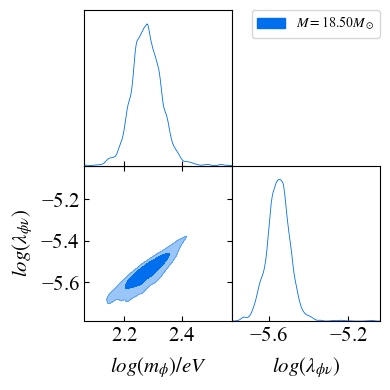

In [24]:
mass = '18.50'

data_2d = np.load('F:/Neutrino_SI/Bin/smellycat260428/data/2d_m'+str(mass)+'_1e6_p32_log_broad.npy')

label_2p = [r'log(m_\phi)/eV', r'log(\lambda_{\phi\nu})']

sample_2p = MCSamples(samples=data_2d, names=label_2p
                    , labels=label_2p, label='1d'
                    )

sample_2p.updateSettings({'smooth_scale_1D': 1.5, 'smooth_scale_2D': 1.5})

g = plots.get_subplot_plotter()
g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 13

# limits = {
# r'log(m_\phi)/eV': [-1, 4], 
# r'log(\lambda_{\phi\nu})': [-10, -3]          
# }

g.triangle_plot([sample_2p], 
                filled=True,          # Keeps contours unfilled like default corner
                # title_limit=2,         # Shows the median and 1-sigma errors in titles
                plot_datapoints=False,
                contour_colors=["#006FED"],
                legend_labels = ['$M=$'+ str(mass) + r'$M_\odot$'],
                # param_limits=limits,
                ) # Ensures scatter points aren't plotted outside contours

g.export(r"F:\Neutrino_SI\Plots\2d_corner_1850.pdf")

g.fig

Removed no burn in


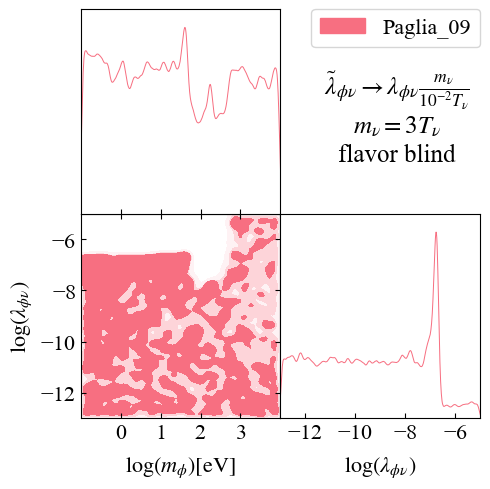

In [7]:
import numpy as np
import corner
from getdist import MCSamples, plots
import corner
import matplotlib.pyplot as plt

model_names = ['Paglia_09', 'Vartan_23']
names = ['log_m_phi', 'log_lambda']
labels = [r'\mathrm{log}(m_\phi)\mathrm{[eV]}', r'\mathrm{log}(\lambda_{\phi\nu})']

data_1d = np.load(r'.\Data\calculation\1d_8p_5e5_p32_log_newscale.npy')
samples_A = MCSamples(samples=data_1d[:,-2:], names=names, labels=labels, label='1d')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

g = plots.get_subplot_plotter(width_inch=5)  

g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 18

samples_A.updateSettings({'contours': [0.68, 0.95, 0.997]})
g.settings.num_plot_contours = 3
g.settings.alpha_filled_add = 0.9
g.settings.solid_contour_palefactor = 0.7
g.settings.alpha_factor_contour_lines = 0


g.triangle_plot(
    samples_A,
    filled=True, 
    contour_colors= ['#f76f81'], # Optional: override default colors
    legend_labels=[model_names[0]], # Optional: legend labels
    param_limits={names[0]: (-1, 4), names[1]: (-13, -5)}
)

my_text = r'$\tilde\lambda_{\phi\nu} \rightarrow \lambda_{\phi\nu}\frac{m_\nu}{10^{-2}T_\nu}$' +'\n' + r'$m_\nu = 3T_\nu$' + '\nflavor blind'
g.fig.text(0.95, 0.85, my_text,
           fontsize=18, 
           ha='right',   # Horizontal alignment: anchors the text to the right side
           va='top',
           multialignment='center')     # Vertical alignment: anchors the text to the top

g.export(r"F:\Neutrino_SI\Plots\1d_corner_newscale.pdf")

g.fig

Removed no burn in


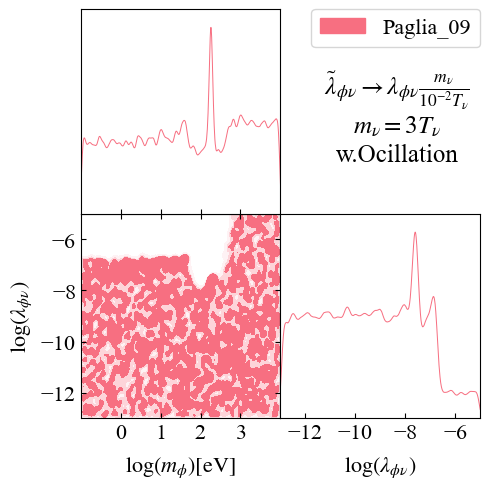

In [6]:
import numpy as np
import corner
from getdist import MCSamples, plots
import corner
import matplotlib.pyplot as plt

model_names = ['Paglia_09', 'Vartan_23']
names = ['log_m_phi', 'log_lambda']
labels = [r'\mathrm{log}(m_\phi)\mathrm{[eV]}', r'\mathrm{log}(\lambda_{\phi\nu})']

data_1d = np.load(r'.\Data\calculation\1d_8p_5e5_p32_log_osc_newscale.npy')
samples_A = MCSamples(samples=data_1d[:,-2:], names=names, labels=labels, label='1d')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

g = plots.get_subplot_plotter(width_inch=5)  

g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 18

samples_A.updateSettings({'contours': [0.68, 0.95, 0.997]})
g.settings.num_plot_contours = 3
g.settings.alpha_filled_add = 0.9
g.settings.solid_contour_palefactor = 0.7
g.settings.alpha_factor_contour_lines = 0


g.triangle_plot(
    samples_A,
    filled=True, 
    contour_colors= ['#f76f81'], # Optional: override default colors
    legend_labels=[model_names[0]], # Optional: legend labels
    param_limits={names[0]: (-1, 4), names[1]: (-13, -5)}
)

my_text = r'$\tilde\lambda_{\phi\nu} \rightarrow \lambda_{\phi\nu}\frac{m_\nu}{10^{-2}T_\nu}$' +'\n' + r'$m_\nu = 3T_\nu$' + '\nw.Ocillation'
g.fig.text(0.95, 0.85, my_text,
           fontsize=18, 
           ha='right',   # Horizontal alignment: anchors the text to the right side
           va='top',
           multialignment='center')     # Vertical alignment: anchors the text to the top

g.export(r"F:\Neutrino_SI\Plots\1d_corner_osc_newscale.pdf")

g.fig